In [268]:
import csv
import numpy as np
from analysis import *
import sys
#import basic libraries

import os
import math
import numpy.linalg as npla
import scipy
from scipy import sparse
from scipy import linalg
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt 
from matplotlib import cm
from scipy.fftpack import fft, fftfreq
from statsmodels.tsa.seasonal import seasonal_decompose

import matplotlib.mlab as mlab
from mpl_toolkits.mplot3d import axes3d
import operator
import mpl_scatter_density
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mtick

import pickle
import powerlaw
from collections import Counter
import random
import pandas as pd
from sklearn import tree
from sklearn.metrics import f1_score
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import (precision_recall_curve,
                             PrecisionRecallDisplay)
from sklearn import metrics

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.utils import resample

import random
random.seed(5)

In [104]:
# Color entropy, size, coalition size, 
input_tile_file = "/scratch/yw180/place/data/sorted_tile_placements.csv"
successful_dir = "/scratch/yw180/place/data/successful_4.csv"
failed_dir = "/scratch/yw180/place/data/unsuccessful_4.csv"

In [23]:
from sklearn.metrics import roc_curve
# ROC
def plot_roc(test_l, pred_l):
    fpr, tpr, thresholds = roc_curve(test_l, pred_l)
    area_under_curve = metrics.auc(fpr, tpr)
    print("ROC AUC is:", area_under_curve)
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=area_under_curve)
    display.plot()
    plt.show()
    
def plot_PR(test_l, pred_l):
    # Precision recall AUC
    precision, recall, _ = precision_recall_curve(test_l, pred_l)
    area_under_curve = metrics.auc(precision, recall)
    print("Precision_recall AUC is:", area_under_curve)
    disp = PrecisionRecallDisplay(precision=precision, recall=recall)
    disp.plot()

In [11]:
def make_update_info_dict(input_file):
    update_info = dict()
    with open(input_file,'r') as file:
        next(file, None)
        reader = csv.reader(file)
        for line in reader:
            update = int(line[0])
            ts = int(int(line[1])/1000)
            user = line[2]
            color = int(line[5])
            x = int(line[3])
            y = int(line[4])
            update_info[update] = [ts, user, color,x,y]
    return update_info

In [177]:
def convert_time_to_decimal(time):
    start_time = 1490918688
    end_time = 1491238734
    total_time = end_time - start_time
    return (time - start_time) / total_time

def make_proj_start_time(succ_file, failed_file, update_info_dict):
    proj_start = dict()
    update_proj = dict()
    with open(succ_file,'r') as file:
        line_count = 0
#         next(file, None)
        reader = csv.reader(file)
        for line in reader:
            name = "s"+str(line_count)
            line_count += 1
            update_lst = sorted([int(x) for x in line])
            for update in update_lst:
                update_proj[update] = name
            time = update_info_dict[update_lst[0]][0]
            proj_start[name] = time
    with open(failed_file,'r') as file:
        line_count = 0
#         next(file, None)
        reader = csv.reader(file)
        for line in reader:
            name = "f"+str(line_count)
            line_count += 1
            update_lst = sorted([int(x) for x in line])
            for update in update_lst:
                update_proj[update] = name
            time = update_info_dict[update_lst[0]][0]
            proj_start[name] = time
    return proj_start, update_proj

In [176]:
def calculate_entropy(data):
    # Count the frequency of each entry
    count = Counter(data)
    
    # Calculate the probability distribution
    total_entries = len(data)
    probabilities = [count[x] / total_entries for x in count]
    
    # Apply the entropy formula
    entropy = -sum(p * math.log2(p) for p in probabilities)
    
    return entropy

def generate_out_line(proj_start, update_info, update_proj, canvas, proj_user,sampled_time):
    line = list()
    proj_color = dict()
    proj_size = dict()
    
    for x in range(0, 1001):
        for y in range(0, 1001):
            update = int(canvas[y,x])
            if update == -1:
                continue
            proj = update_proj[update]
            if proj not in proj_color:
                proj_color[proj] = [update_info[update][2]]
                proj_size[proj] = 1
            else:
                proj_color[proj].append(update_info[update][2])
                proj_size[proj] += 1
    for proj in proj_color:
        succ = 0
        if proj[0] == 's':
            succ = 1
        start_time = convert_time_to_decimal(proj_start[proj])
        size = proj_size[proj]
        num_user = len(proj_user[proj])
        ent = calculate_entropy(proj_color[proj])
        out = [start_time, size,num_user,ent, sampled_time,succ]
        line.append(out)
    return line

def generate_data(out, proj_start, update_info, update_proj, timestamp_lst):
    data = list()
    canvas = np.array(-1 * np.ones((1001, 1001)))

    curr_lst_idx = 0
    proj_user = dict()
    with open(out, 'w') as out_file:
        writer = csv.writer(out_file, delimiter = ",")
        writer.writerow(["start_time", "artwork size", "coalition size", "color entropy", "sampled_time", "successful"])
        for i in range(max(update_info.keys()) + 1):
            if i not in update_info:
                continue
            timestamp = update_info[i][0]
            if timestamp > timestamp_lst[curr_lst_idx]:
                lines = generate_out_line(proj_start, update_info, update_proj, canvas, proj_user, timestamp_lst[curr_lst_idx])
                writer.writerows(lines)
                curr_lst_idx += 1
                if curr_lst_idx >= len(timestamp_lst):
                    break
            if i not in update_proj:
                continue
            proj = update_proj[i]
            user = update_info[i][1]
            if proj not in proj_user:
                proj_user[proj] = {user}
            else:
                proj_user[proj].add(user)
            x = update_info[i][3]
            y = update_info[i][4]
            canvas[y,x] = i


In [14]:
update_info = make_update_info_dict(input_tile_file)

In [15]:
proj_start, update_proj = make_proj_start_time(successful_dir, failed_dir,update_info)

In [47]:
out = "/scratch/yw180/place/pred_data.csv"

In [95]:
start = 1490918688
end = 1491238734
rand_timestamps = random.sample(range(start, end + 1), 100)

In [96]:
rand_timestamps = sorted(rand_timestamps)

In [178]:
generate_data(out,proj_start,update_info,update_proj,rand_timestamps)

# Decision Tree

In [339]:
#"start_time, artwork size, coalition size, color entropy, successful"
data = list()
with open("/scratch/yw180/place/pred_data_no_dup.csv", "r") as file:
    next(file, None)
    reader = csv.reader(file)
    for line in reader:
        lst = list()
        st = float(line[0])
        a_s = int(line[1])
        c_s = int(line[2])
        ent = float(line[3])
        succ = int(line[4])
        lst = [st, a_s, c_s, ent, succ]
        data.append(lst)

In [386]:
df = pd.read_csv("/scratch/yw180/place/pred_data_no_dup.csv", names=["start_time", "artwork size", "coalition size", "color entropy", "sampled_time","successful"], skiprows=1)
df = df.drop(columns=['sampled_time']).drop_duplicates()
labels = df['successful'].to_numpy()

In [387]:
df["successful"].value_counts()

successful
0    82248
1    27256
Name: count, dtype: int64

In [388]:
27256/(27256+82248)

0.2489041496201052

In [343]:
succ = df[df["successful"] == 1]
failed  = df[df["successful"] == 0]

In [344]:
failed_down = resample(failed,
             replace=True,
             n_samples=len(succ),
             random_state=5)

print(failed_down.shape)

(27256, 5)


In [345]:
randomized_idx_succ = random.sample(range(len(succ)), len(succ))
randomized_idx_failed = random.sample(range(len(failed)), len(failed))
train_idx_succ = randomized_idx_succ[:int(len(succ)*0.9)]
test_idx_succ = randomized_idx_succ[int(len(succ)*0.9):]
train_idx_failed = randomized_idx_failed[:int(len(succ)*0.9)]
test_idx_failed = randomized_idx_failed[int(len(succ)*0.9):]

In [346]:
succ_rows_train = succ.iloc[train_idx_succ]
succ_rows_test = succ.iloc[test_idx_succ]
failed_rows_train = failed.iloc[train_idx_failed]
failed_rows_test = failed.iloc[test_idx_failed]

In [347]:
df_train = pd.concat([succ_rows_train, failed_rows_train])
df_test = pd.concat([succ_rows_test,failed_rows_test])

In [348]:
train_f = df_train.drop(columns = ['successful']).to_numpy()
train_l = df_train['successful'].to_numpy()
test_f = df_test.drop(columns=['successful']).to_numpy()
test_l = df_test['successful'].to_numpy()

In [349]:
clf = tree.DecisionTreeClassifier(criterion='entropy')
clf.fit(train_f, train_l)

# Calculate entropy at each node
value = clf.tree_.value
prob = value[:, 0] / value[:, 0].sum(axis=1, keepdims=True)
entropy = -np.sum(prob * np.log2(prob + 1e-9), axis=1)

avg_entropy = np.mean(entropy)
print("average entropy of node is:", avg_entropy)

samples = clf.tree_.n_node_samples
weighted_avg_entropy = np.sum(entropy * samples) / np.sum(samples)
print("weighted avg. entropy:", weighted_avg_entropy)

average entropy of node is: 0.36613705443689853
weighted avg. entropy: 0.6009136880002739


In [350]:
clf = tree.DecisionTreeClassifier()
clf = clf.fit(train_f, train_l)
pred_l = clf.predict(test_f)

F1 Score is: 0.3739204854897689
ROC AUC is: 0.8738441505905571


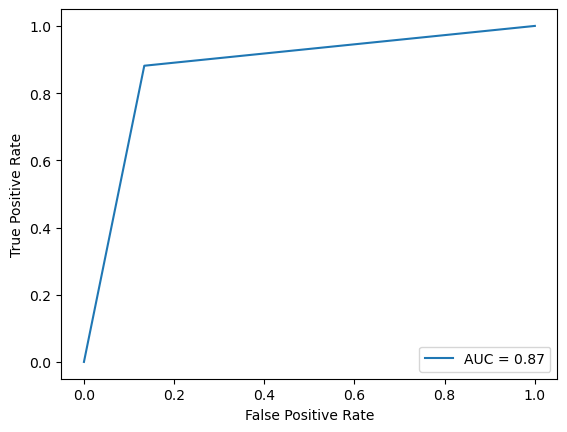

Precision_recall AUC is: 0.5169712152792394


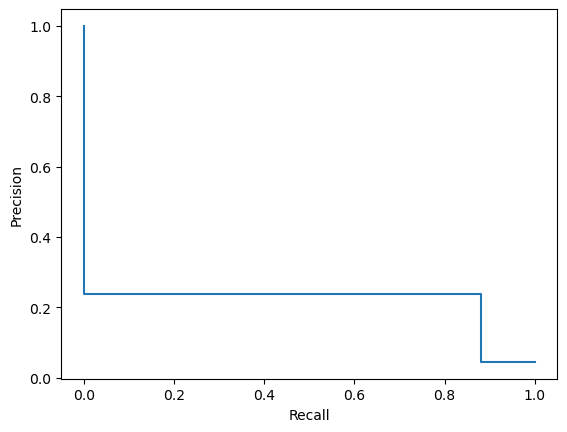

In [351]:
# f1 score
fs = f1_score(pred_l, test_l)
print("F1 Score is:",fs)
plot_roc(test_l, pred_l)
plot_PR(test_l, pred_l)

In [352]:
probabilities = clf.predict_proba(test_f)

count_succ = (probabilities[:, 1] > 0.5).sum()
p = count_succ / len(probabilities)
print(p)

0.16754351134934817


In [353]:
leaf_nodes = []
t = clf.tree_
for node in range(t.node_count):
    # Check if the node is a leaf (no children)
    if t.children_left[node] == -1 and t.children_right[node] == -1:
        leaf_nodes.append(node)

succ_count = 0
total = 0
for leaf in leaf_nodes:
    if t.value[leaf][0][1] > t.value[leaf][0][0]:
        succ_count += t.value[leaf][0][1]
    total += t.value[leaf][0][0] + t.value[leaf][0][1]
print(succ_count / total)

0.49981655116184265


# Random Forest

In [171]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, random_state=5,criterion='entropy')
clf.fit(train_f, train_l)
pred_l = clf.predict(test_f)


In [172]:

def compute_entropy_per_tree(tree):
    value = tree.tree_.value  # shape: (n_nodes, 1, n_classes)
    prob = value[:, 0] / value[:, 0].sum(axis=1, keepdims=True)
    entropy = -np.sum(prob * np.log2(prob + 1e-9), axis=1)  # small value to avoid log(0)
    return entropy

entropies = [compute_entropy_per_tree(estimator) for estimator in clf.estimators_]

In [174]:
all_entropy = np.concatenate(entropies)
avg_entropy = np.mean(all_entropy)

# Weighted average by number of samples per node
weighted_entropy = []
total_samples = 0
for estimator in clf.estimators_:
    ent = compute_entropy_per_tree(estimator)
    samples = estimator.tree_.n_node_samples
    weighted_entropy.append(np.sum(ent * samples))
    total_samples += np.sum(samples)

weighted_avg_entropy = np.sum(weighted_entropy) / total_samples
print("weighted avg entropy", weighted_avg_entropy)

weighted avg entropy 0.616507454375735


F1 Score is: 0.4705995388162951
ROC AUC is: 0.9038604781102706


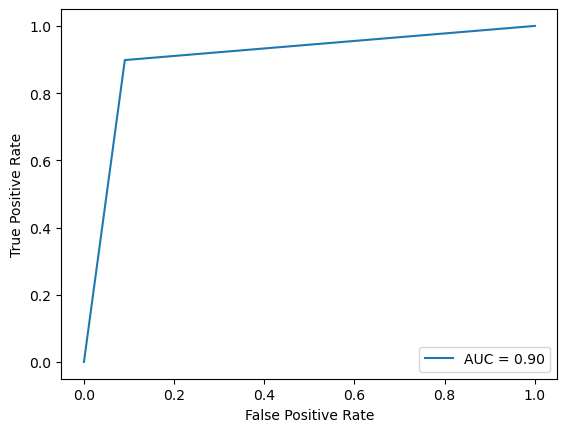

Precision_recall AUC is: 0.5657833316511662


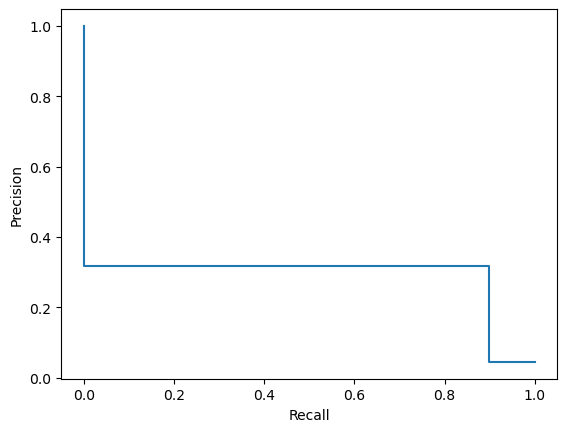

In [175]:
# f1 score
fs = f1_score(pred_l, test_l)
print("F1 Score is:",fs)
plot_roc(test_l, pred_l)
plot_PR(test_l, pred_l)

# Separate data: first 48 hours

In [374]:
start_time = 1490918688
first_48_mark = start_time + 48 * 3600

In [375]:
df = pd.read_csv("/scratch/yw180/place/pred_data_no_dup.csv", names=["start_time", "artwork size", "coalition size", "color entropy", "sampled_time","successful"], skiprows=1)


In [376]:
first_48_df = df[df['sampled_time'] < first_48_mark].drop(columns = ["sampled_time"]).drop_duplicates()
print(first_48_df["successful"].value_counts())

successful
0    50675
1     7096
Name: count, dtype: int64


In [389]:
7096 / (7096+50675)

0.12282979349500614

In [377]:
succ = first_48_df[first_48_df["successful"] == 1]
failed  = first_48_df[first_48_df["successful"] == 0]

In [378]:
randomized_idx_succ = random.sample(range(len(succ)), len(succ))
randomized_idx_failed = random.sample(range(len(failed)), len(failed))
train_idx_succ = randomized_idx_succ[:int(len(succ)*0.9)]
test_idx_succ = randomized_idx_succ[int(len(succ)*0.9):]
train_idx_failed = randomized_idx_failed[:int(len(succ)*0.9)]
test_idx_failed = randomized_idx_failed[int(len(succ)*0.9):]

In [379]:
succ_rows_train = succ.iloc[train_idx_succ]
succ_rows_test = succ.iloc[test_idx_succ]
failed_rows_train = failed.iloc[train_idx_failed]
failed_rows_test = failed.iloc[test_idx_failed]

In [380]:
df_train = pd.concat([succ_rows_train, failed_rows_train])
df_test = pd.concat([succ_rows_test,failed_rows_test])

In [381]:
train_f = df_train.drop(columns = ['successful']).to_numpy()
train_l = df_train['successful'].to_numpy()
test_f = df_test.drop(columns=['successful']).to_numpy()
test_l = df_test['successful'].to_numpy()

In [382]:
clf = tree.DecisionTreeClassifier(criterion='entropy')
clf.fit(train_f, train_l)

# Calculate entropy at each node
value = clf.tree_.value
prob = value[:, 0] / value[:, 0].sum(axis=1, keepdims=True)
entropy = -np.sum(prob * np.log2(prob + 1e-9), axis=1)

avg_entropy = np.mean(entropy)
print("average entropy of node is:", avg_entropy)

samples = clf.tree_.n_node_samples
weighted_avg_entropy = np.sum(entropy * samples) / np.sum(samples)
print("weighted avg. entropy:", weighted_avg_entropy)

average entropy of node is: 0.3814774581024327
weighted avg. entropy: 0.6435947254407625


F1 Score is: 0.11544431509507179
ROC AUC is: 0.8173748512888617


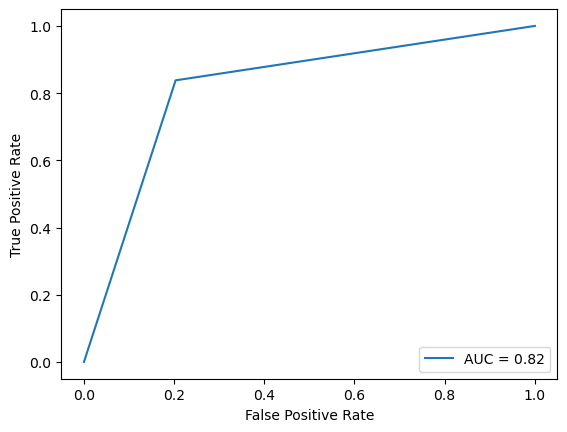

Precision_recall AUC is: 0.43550980311950144


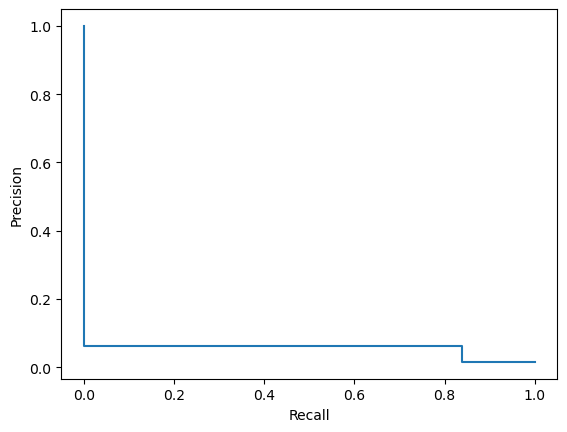

In [383]:
# f1 score
pred_l = clf.predict(test_f)
fs = f1_score(pred_l, test_l)
print("F1 Score is:",fs)
plot_roc(test_l, pred_l)
plot_PR(test_l, pred_l)

In [384]:
probabilities = clf.predict_proba(test_f)

count_succ = (probabilities[:, 1] > 0.5).sum()
p = count_succ / len(probabilities)
print(p)

0.2132936287473055


In [385]:
leaf_nodes = []
t = clf.tree_
for node in range(t.node_count):
    # Check if the node is a leaf (no children)
    if t.children_left[node] == -1 and t.children_right[node] == -1:
        leaf_nodes.append(node)

succ_count = 0
total = 0
for leaf in leaf_nodes:
    if t.value[leaf][0][1] > t.value[leaf][0][0]:
        succ_count += 1
    total += 1
print(succ_count / total)

0.49412915851272016


In [337]:
t.value[14][0][0]

11.0

In [322]:
t.value[13]

array([[0., 1.]])

# 48 hour - end

In [366]:
df = pd.read_csv("/scratch/yw180/place/pred_data_no_dup.csv", names=["start_time", "artwork size", "coalition size", "color entropy", "sampled_time","successful"], skiprows=1)

last_48_df = df[df['sampled_time'] >= first_48_mark].drop(columns = ["sampled_time"]).drop_duplicates()
print(last_48_df["successful"].value_counts())

successful
0    31789
1    20200
Name: count, dtype: int64


In [390]:
20200/(31789+20200)

0.3885437304045086

In [367]:
succ = last_48_df[last_48_df["successful"] == 1]
failed  = last_48_df[last_48_df["successful"] == 0]
randomized_idx_succ = random.sample(range(len(succ)), len(succ))
randomized_idx_failed = random.sample(range(len(failed)), len(failed))
train_idx_succ = randomized_idx_succ[:int(len(succ)*0.9)]
test_idx_succ = randomized_idx_succ[int(len(succ)*0.9):]
train_idx_failed = randomized_idx_failed[:int(len(succ)*0.9)]
test_idx_failed = randomized_idx_failed[int(len(succ)*0.9):]
succ_rows_train = succ.iloc[train_idx_succ]
succ_rows_test = succ.iloc[test_idx_succ]
failed_rows_train = failed.iloc[train_idx_failed]
failed_rows_test = failed.iloc[test_idx_failed]
df_train = pd.concat([succ_rows_train, failed_rows_train])
df_test = pd.concat([succ_rows_test,failed_rows_test])
train_f = df_train.drop(columns = ['successful']).to_numpy()
train_l = df_train['successful'].to_numpy()
test_f = df_test.drop(columns=['successful']).to_numpy()
test_l = df_test['successful'].to_numpy()

In [368]:
clf = tree.DecisionTreeClassifier(criterion='entropy')
clf.fit(train_f, train_l)

# Calculate entropy at each node
value = clf.tree_.value
prob = value[:, 0] / value[:, 0].sum(axis=1, keepdims=True)
entropy = -np.sum(prob * np.log2(prob + 1e-9), axis=1)

avg_entropy = np.mean(entropy)
print("average entropy of node is:", avg_entropy)

samples = clf.tree_.n_node_samples
weighted_avg_entropy = np.sum(entropy * samples) / np.sum(samples)
print("weighted avg. entropy:", weighted_avg_entropy)

average entropy of node is: 0.3549098826770449
weighted avg. entropy: 0.6233669573171593


In [369]:
 clf.tree_.value

array([[[1.8180e+04, 1.8180e+04]],

       [[1.4015e+04, 3.9470e+03]],

       [[9.0710e+03, 1.3950e+03]],

       ...,

       [[2.0000e+00, 0.0000e+00]],

       [[0.0000e+00, 7.0000e+00]],

       [[0.0000e+00, 1.8100e+02]]])

F1 Score is: 0.7560483870967742
ROC AUC is: 0.9249803929985181


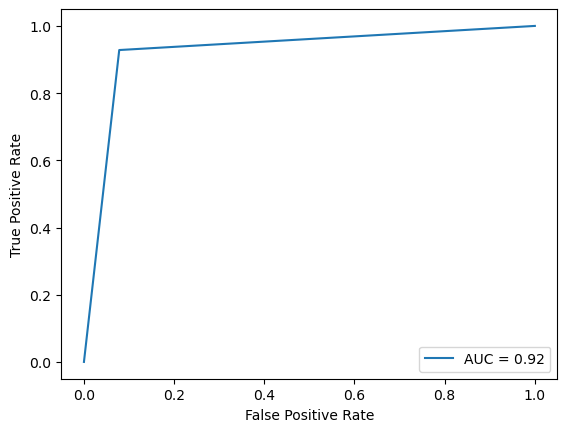

Precision_recall AUC is: 0.6583783615851808


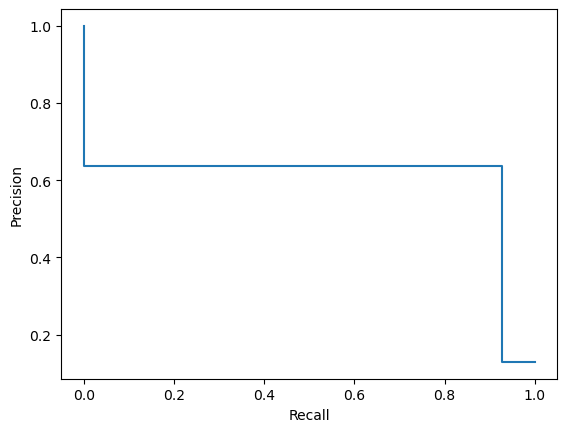

In [370]:
# f1 score
pred_l = clf.predict(test_f)
fs = f1_score(pred_l, test_l)
print("F1 Score is:",fs)
plot_roc(test_l, pred_l)
plot_PR(test_l, pred_l)

In [371]:
probabilities = clf.predict_proba(test_f)

count_succ = (probabilities[:, 1] > 0.5).sum()
p = count_succ / len(probabilities)
print(p)

0.18811184336809778


In [373]:
leaf_nodes = []
t = clf.tree_
for node in range(t.node_count):
    # Check if the node is a leaf (no children)
    if t.children_left[node] == -1 and t.children_right[node] == -1:
        leaf_nodes.append(node)

succ_count = 0
total = 0
for leaf in leaf_nodes:
    if t.value[leaf][0][1] > t.value[leaf][0][0]:
        succ_count += 1
    total += 1
print(succ_count / total)

0.4749021003915984


# 72 hours - end

In [206]:
first_72_mark = start_time + 72 * 3600
last_72_df = df[df['sampled_time'] >= first_72_mark]
print(last_72_df["successful"].value_counts())

successful
0    9347
1    8760
Name: count, dtype: int64


In [208]:
succ = last_72_df[last_72_df["successful"] == 1]
failed  = last_72_df[last_72_df["successful"] == 0]
randomized_idx_succ = random.sample(range(len(succ)), len(succ))
randomized_idx_failed = random.sample(range(len(failed)), len(failed))
train_idx_succ = randomized_idx_succ[:int(len(succ)*0.9)]
test_idx_succ = randomized_idx_succ[int(len(succ)*0.9):]
train_idx_failed = randomized_idx_failed[:int(len(succ)*0.9)]
test_idx_failed = randomized_idx_failed[int(len(succ)*0.9):]
succ_rows_train = succ.iloc[train_idx_succ]
succ_rows_test = succ.iloc[test_idx_succ]
failed_rows_train = failed.iloc[train_idx_failed]
failed_rows_test = failed.iloc[test_idx_failed]
df_train = pd.concat([succ_rows_train, failed_rows_train])
df_test = pd.concat([succ_rows_test,failed_rows_test])
train_f = df_train.drop(columns = ['successful','sampled_time']).to_numpy()
train_l = df_train['successful'].to_numpy()
test_f = df_test.drop(columns=['successful','sampled_time']).to_numpy()
test_l = df_test['successful'].to_numpy()

In [209]:
clf = tree.DecisionTreeClassifier(criterion='entropy')
clf.fit(train_f, train_l)

# Calculate entropy at each node
value = clf.tree_.value
prob = value[:, 0] / value[:, 0].sum(axis=1, keepdims=True)
entropy = -np.sum(prob * np.log2(prob + 1e-9), axis=1)

avg_entropy = np.mean(entropy)
print("average entropy of node is:", avg_entropy)

samples = clf.tree_.n_node_samples
weighted_avg_entropy = np.sum(entropy * samples) / np.sum(samples)
print("weighted avg. entropy:", weighted_avg_entropy)

average entropy of node is: 0.3286600123978567
weighted avg. entropy: 0.5566334592229487


F1 Score is: 0.9303621169916434
ROC AUC is: 0.9478900395446899


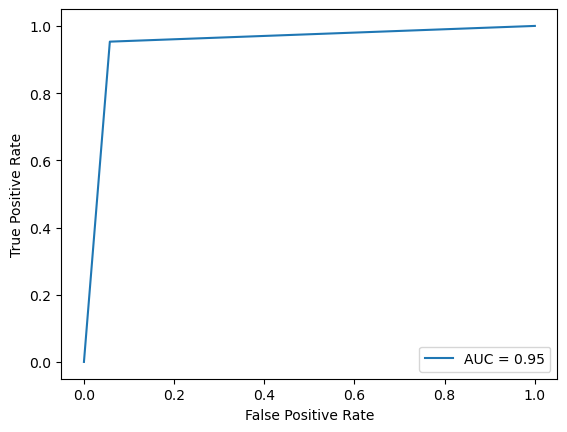

Precision_recall AUC is: 0.5651417276980141


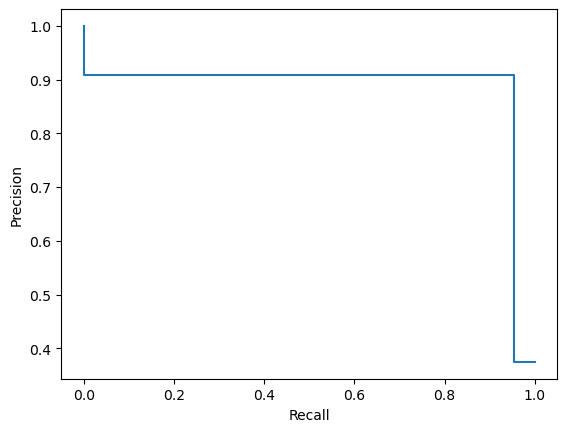

In [210]:
# f1 score
pred_l = clf.predict(test_f)
fs = f1_score(pred_l, test_l)
print("F1 Score is:",fs)
plot_roc(test_l, pred_l)
plot_PR(test_l, pred_l)

In [211]:
pred_l

array([1, 0, 1, ..., 0, 0, 0])